# 📊 Projet AfriMarket — Analyse Stratégique des Données E-commerce

**Formation : Maîtrisez l'Analyse des Données avec Claude**
Module pratique — Python / Pandas / Matplotlib / Seaborn

---

## Contexte business

AfriMarket est une entreprise e-commerce panafricaine vendant dans 4 catégories
(Électronique, Mode, Beauté, Maison) dans plusieurs villes d'Afrique francophone.
La direction constate des variations de chiffre d'affaires, un taux de retour
préoccupant, des dépenses marketing élevées et des écarts de performance selon
les villes.

**Ta mission (Data Analyst) :** auditer les données, les nettoyer, construire des
indicateurs business, produire des analyses actionnables et un dashboard.

## Comment utiliser ce notebook

Ce notebook est pensé pour être suivi **en parallèle d'une conversation avec
Claude**. À chaque étape clé, tu trouveras un encadré `💡 Prompt Claude` qui te
montre le prompt exact à utiliser pour comprendre, adapter, ou faire critiquer
le code par Claude. Ne copie jamais du code sans comprendre *pourquoi* il est
écrit ainsi.

**Plan du notebook :**
1. Chargement des données
2. Audit & compréhension
3. Data Cleaning → `df_clean`
4. Feature Engineering
5. Analyses (performance globale, catégories, géographie, marketing, clients)
6. Résumé exécutif & recommandations


## 1️⃣ Chargement des données

> 💡 **Prompt Claude — Premier contact avec un dataset**
>
> ```
> Voici un dataset CSV que je dois analyser pour une entreprise e-commerce. Aide-moi à écrire le code Python (pandas) pour le charger et me donner un premier aperçu : dimensions, colonnes, types, 5 premières lignes.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
COULEUR_PRINCIPALE = "#D97757"  # terracotta

df = pd.read_csv("afrimarket_dataset_senior.csv")
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 10100 lignes x 14 colonnes


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


**Colonnes disponibles :** `id_commande`, `date_commande`, `id_client`,
`ville`, `categorie`, `nom_produit`, `prix_unitaire`, `quantite`, `remise`,
`cout_livraison`, `methode_paiement`, `canal_marketing`, `cout_marketing`,
`statut_commande`.

⚠️ Point important : `remise` est ici un **pourcentage** (ex. 0.10 = 10 % de
remise), pas un montant en dollars — on le vérifiera dans l'audit.

## 2️⃣ Audit & Compréhension des données

Avant de nettoyer quoi que ce soit, on documente **précisément** les problèmes.
Un audit bâclé = un cleaning bâclé = des analyses fausses.

> 💡 **Prompt Claude — Audit de structure**
>
> ```
> Fais un audit complet de ce dataframe pandas : types de colonnes, valeurs manquantes (nombre et %), doublons exacts, doublons sur l'identifiant de commande. Présente les résultats de façon lisible.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [2]:
print("=== TYPES DE DONNÉES ===")
print(df.dtypes)

print("\n=== VALEURS MANQUANTES ===")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"manquants": missing, "%": missing_pct}))

print("\n=== DOUBLONS ===")
print(f"Doublons exacts (toutes colonnes) : {df.duplicated().sum()}")
print(f"Doublons sur id_commande           : {df.duplicated(subset=['id_commande']).sum()}")

=== TYPES DE DONNÉES ===
id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object

=== VALEURS MANQUANTES ===
                  manquants    %
id_commande               0  0.0
date_commande             0  0.0
id_client                 0  0.0
ville                     0  0.0
categorie                 0  0.0
nom_produit               0  0.0
prix_unitaire             0  0.0
quantite                  0  0.0
remise                    0  0.0
cout_livraison            0  0.0
methode_paiement          0  0.0
canal_marketing           0  0.0
cout_marketing            0  0.0
statut_commande           0  0.0

=== DOUBLONS ===
Doublons exacts (toutes colo

**Constat :** ce dataset ne contient pas de valeurs manquantes (rare dans
la vraie vie, mais ça arrive), mais il contient bien 100 doublons exacts
identifiés à la fois sur toutes les colonnes et sur `id_commande` — donc
un vrai doublon de commande, pas juste un id qui se répète avec des valeurs
différentes.

In [3]:
print("=== VALEURS UNIQUES DES COLONNES CATÉGORIELLES (avant nettoyage) ===")
for col in ["ville", "categorie", "methode_paiement", "canal_marketing", "statut_commande"]:
    print(f"\n--- {col} ({df[col].nunique()} valeurs uniques) ---")
    print(df[col].value_counts(dropna=False))

=== VALEURS UNIQUES DES COLONNES CATÉGORIELLES (avant nettoyage) ===

--- ville (9 valeurs uniques) ---
ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

--- categorie (5 valeurs uniques) ---
categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64

--- methode_paiement (4 valeurs uniques) ---
methode_paiement
Paiement à la livraison    2561
Mobile Money               2529
Virement                   2508
Carte                      2502
Name: count, dtype: int64

--- canal_marketing (4 valeurs uniques) ---
canal_marketing
Instagram Ads    4045
Google Ads       2552
Email            2049
Influenceur      1454
Name: count, dtype: int64

--- statut_commande (3 valeurs uniques) ---
statut_commande
Livrée       9080
retournée     826
Annulée       1

**Constat :** on repère deux incohérences de saisie classiques :
- `ville` : `Kinshassa` (605 lignes) est une faute de frappe de `Kinshasa` (2349 lignes)
- `categorie` : `electronique` (606 lignes, minuscule) est une variante de `Électronique` (2638 lignes)

En revanche, `methode_paiement`, `canal_marketing` et `statut_commande` n'ont
qu'un seul petit problème de casse à corriger (`retournée` vs `Retournée`/
`Livrée`/`Annulée`) — ce dataset est **plus propre** que ce qu'on croise
parfois, mais les valeurs numériques cachent des problèmes plus sérieux,
comme on va le voir.

> 💡 **Prompt Claude — Détection de valeurs aberrantes**
>
> ```
> Aide-moi à détecter les valeurs aberrantes ou incohérentes dans les colonnes numériques prix_unitaire, quantite et remise d'un dataframe de commandes e-commerce. Utilise des statistiques descriptives et des seuils métier raisonnables.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [4]:
print("=== STATISTIQUES DESCRIPTIVES ===")
print(df[["prix_unitaire", "quantite", "remise", "cout_livraison", "cout_marketing"]].describe())

print("\n=== ANOMALIES DÉTECTÉES ===")
print(f"Prix négatifs ou nuls   : {(df['prix_unitaire'] <= 0).sum()}")
print(f"Quantité à 0            : {(df['quantite'] == 0).sum()}")
print(f"Remises négatives       : {(df['remise'] < 0).sum()}")
print(f"Valeurs de remise triées: {sorted(df['remise'].unique())[:5]} ... {sorted(df['remise'].unique())[-5:]}")

=== STATISTIQUES DESCRIPTIVES ===
       prix_unitaire      quantite        remise  cout_livraison  \
count   10100.000000  10100.000000  10100.000000    10100.000000   
mean      140.493353      1.866040      0.111422        6.008478   
std       172.031607      0.920966      0.098352        2.304953   
min       -50.000000      0.000000     -0.100000        2.000000   
25%        28.057500      1.000000      0.050000        4.040000   
50%        52.975000      2.000000      0.090000        5.990000   
75%       201.885000      3.000000      0.190000        8.030000   
max       915.860000      3.000000      0.300000       10.000000   

       cout_marketing  
count    10100.000000  
mean         7.388465  
std          4.638945  
min          0.500000  
25%          3.980000  
50%          6.870000  
75%         10.850000  
max         19.980000  

=== ANOMALIES DÉTECTÉES ===
Prix négatifs ou nuls   : 632
Quantité à 0            : 608
Remises négatives       : 614
Valeurs de remise 

### 🔎 Investigation des prix négatifs

Un `prix_unitaire` négatif n'a pas de sens métier. Mais est-ce une simple
erreur de signe (le prix réel serait la valeur absolue) ou une valeur
d'erreur générique injectée par le système ? On compare la distribution des
prix négatifs à celle des prix positifs, par catégorie.

In [5]:
prix_positifs = df[df["prix_unitaire"] > 0].groupby("categorie")["prix_unitaire"].describe()
prix_negatifs = df[df["prix_unitaire"] < 0].groupby("categorie")["prix_unitaire"].describe()
print("Prix positifs par catégorie :")
print(prix_positifs[["mean", "50%", "max"]])
print("\nPrix négatifs par catégorie :")
print(prix_negatifs[["mean", "50%", "min"]])

Prix positifs par catégorie :
                    mean      50%     max
categorie                                
Beauté         24.969905   24.995   51.04
Maison        119.235972  119.685  263.98
Mode           40.225684   40.040   95.37
electronique  152.409137   61.940  776.12
Électronique  401.033675  402.970  915.86

Prix négatifs par catégorie :
                   mean   50%   min
categorie                          
Beauté       -49.194615 -50.0 -50.0
Maison       -47.697155 -50.0 -50.0
Mode         -47.793825 -50.0 -50.0
electronique -47.939737 -50.0 -50.0
Électronique -49.579607 -50.0 -50.0


**Constat clé :** les prix négatifs tournent tous autour de **-50**, quelle
que soit la catégorie (même en Électronique, où le prix moyen réel dépasse
350 $). Ce n'est donc **pas** un simple signe inversé (sinon on retrouverait
la même échelle de prix que la catégorie) : c'est une **valeur d'erreur
générique** (probablement un code d'erreur système ou une valeur par défaut
mal gérée). La bonne correction n'est donc pas `abs()`, mais un remplacement
par une estimation raisonnable (médiane de la catégorie) — exactement le
genre de vérification qu'il faut faire *avant* de corriger, pas après.

### 🔎 Investigation des remises négatives

Même logique : on regarde si `-0.1` est une valeur isolée ou dispersée.

In [6]:
print(df[df["remise"] < 0]["remise"].describe())

count    6.140000e+02
mean    -1.000000e-01
std      1.388910e-17
min     -1.000000e-01
25%     -1.000000e-01
50%     -1.000000e-01
75%     -1.000000e-01
max     -1.000000e-01
Name: remise, dtype: float64


**Constat :** toutes les remises négatives valent exactement `-0.1`, une
valeur sentinelle d'erreur (pas une distribution continue comme les prix
négatifs). C'est cohérent avec une remise de `10%` mal signée à la saisie.
Dans les deux cas (prix et remise), corriger sans vérifier au préalable
aurait été une erreur méthodologique.

### Résumé d'audit

| Problème | Détail |
|---|---|
| Ville mal orthographiée | `Kinshassa` → `Kinshasa` (605 lignes) |
| Catégorie casse incohérente | `electronique` → `Électronique` (606 lignes) |
| Statut casse incohérente | `retournée` → `Retournée` |
| Doublons exacts | 100 commandes dupliquées |
| Prix invalides | ~622 lignes avec un prix ≤ 0 (valeur sentinelle ~-50, indépendante de la catégorie) |
| Remises négatives | ~600 lignes à `-0.1` (valeur sentinelle) |
| Quantités nulles | ~600 commandes "fantômes" (quantite = 0) |
| Remise = pourcentage, pas un montant | à appliquer en multiplicateur, pas en soustraction directe |

➡️ Tous ces problèmes doivent être corrigés **avant** de calculer le moindre
indicateur business.

## 3️⃣ Data Cleaning

On construit `df_clean` **sans jamais modifier `df`**.

> 💡 **Prompt Claude — Supprimer des doublons de commande**
>
> ```
> J'ai un dataframe de commandes avec un identifiant id_commande. Certaines lignes sont des doublons exacts. Aide-moi à les supprimer proprement, en gardant la première occurrence.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [7]:
df_clean = df.copy()

# --- 3.1 Doublons ---
n_avant = len(df_clean)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=["id_commande"], keep="first")
print(f"Doublons supprimés : {n_avant - len(df_clean)}")

# --- 3.2 Dates ---
df_clean["date_commande"] = pd.to_datetime(df_clean["date_commande"], format="%Y-%m-%d", errors="coerce")
print(f"Dates non reconnues après parsing : {df_clean['date_commande'].isna().sum()}")

Doublons supprimés : 100
Dates non reconnues après parsing : 0


> 💡 **Prompt Claude — Uniformiser des catégories textuelles**
>
> ```
> J'ai une colonne 'ville' avec une faute de frappe qui désigne en réalité la même ville (ex: 'Kinshassa' pour 'Kinshasa'). Aide-moi à construire un dictionnaire de correspondance et à l'appliquer avec .replace().
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [8]:
# --- 3.3 Villes ---
ville_map = {"Kinshassa": "Kinshasa"}
df_clean["ville"] = df_clean["ville"].str.strip().replace(ville_map)
print("Villes après nettoyage :", sorted(df_clean["ville"].unique()))

# --- 3.4 Catégories ---
cat_map = {"electronique": "Électronique"}
df_clean["categorie"] = df_clean["categorie"].str.strip().replace(cat_map)
print("Catégories après nettoyage :", sorted(df_clean["categorie"].unique()))

# --- 3.5 Statuts ---
statut_map = {"retournée": "Retournée"}
df_clean["statut_commande"] = df_clean["statut_commande"].str.strip().replace(statut_map)
print("Statuts après nettoyage :", sorted(df_clean["statut_commande"].unique()))

Villes après nettoyage : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']
Catégories après nettoyage : ['Beauté', 'Maison', 'Mode', 'Électronique']
Statuts après nettoyage : ['Annulée', 'Livrée', 'Retournée']


> 💡 **Prompt Claude — Gérer des remises négatives et des prix aberrants après investigation**
>
> ```
> Dans mon dataframe, 'remise' contient parfois -0.1 (valeur sentinelle d'erreur, une remise ne peut pas être négative), et 'prix_unitaire' contient des valeurs négatives autour de -50 qui ne sont PAS proportionnelles à la catégorie (donc pas un simple signe inversé). Propose une correction adaptée à chaque cas.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [9]:
# --- 3.6 Remises négatives -> 0 (valeur sentinelle, une remise ne peut pas être négative) ---
n_remise_neg = (df_clean["remise"] < 0).sum()
df_clean.loc[df_clean["remise"] < 0, "remise"] = 0
print(f"{n_remise_neg} remises négatives corrigées à 0")

# --- 3.7 Prix invalides (<=0) -> médiane de la catégorie ---
# (voir investigation dans l'audit : ce n'est pas un signe inversé, donc pas de abs())
median_prix_cat = df_clean[df_clean["prix_unitaire"] > 0].groupby("categorie")["prix_unitaire"].median()
n_prix_invalide = (df_clean["prix_unitaire"] <= 0).sum()
df_clean.loc[df_clean["prix_unitaire"] <= 0, "prix_unitaire"] = (
    df_clean.loc[df_clean["prix_unitaire"] <= 0, "categorie"].map(median_prix_cat)
)
print(f"{n_prix_invalide} prix invalides corrigés par la médiane de leur catégorie")

# --- 3.8 Quantités nulles -> suppression (commande fantôme, pas une vraie vente) ---
n_qte_0 = (df_clean["quantite"] == 0).sum()
df_clean = df_clean[df_clean["quantite"] > 0]
print(f"{n_qte_0} lignes à quantité nulle supprimées")

df_clean = df_clean.dropna(subset=["date_commande"]).reset_index(drop=True)
print(f"\nShape final de df_clean : {df_clean.shape}  (vs {df.shape} pour df brut)")

600 remises négatives corrigées à 0
622 prix invalides corrigés par la médiane de leur catégorie
600 lignes à quantité nulle supprimées

Shape final de df_clean : (9400, 14)  (vs (10100, 14) pour df brut)


> ⚠️ **Note pédagogique — toujours investiguer avant de corriger.**
> Si on avait corrigé les prix négatifs avec un simple `abs()` sans vérifier
> leur distribution par catégorie, on aurait introduit des prix aberrants
> (ex. -50 devenu 50 pour un produit Électronique qui vaut normalement
> 350 $ en moyenne). C'est l'étape d'investigation, pas la correction en
> elle-même, qui distingue un cleaning rigoureux d'un cleaning mécanique.

## 4️⃣ Feature Engineering

On construit les indicateurs business qui serviront à toutes les analyses.

> 💡 **Prompt Claude — Créer des indicateurs business à partir de données brutes**
>
> ```
> À partir d'un dataframe de commandes e-commerce (prix_unitaire, quantite, remise en pourcentage, cout_marketing, cout_livraison, date_commande, statut_commande, id_client), aide-moi à créer : le chiffre d'affaires par ligne (attention, remise est un %, pas un montant), une marge brute estimée, un profit net estimé (marge - coûts marketing et livraison), le mois, un indicateur de retour, le nombre de commandes par client, et une CLV simplifiée.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [10]:
# Chiffre d'affaires : remise est un POURCENTAGE (0 à 0.3), pas un montant en $
df_clean["chiffre_affaires"] = df_clean["prix_unitaire"] * df_clean["quantite"] * (1 - df_clean["remise"])

# Marge brute estimée : hypothèse métier documentée (marge moyenne e-commerce ~42%),
# faute de coût d'achat réel par produit dans le dataset
MARGE_BRUTE_PCT = 0.42
df_clean["marge_brute"] = df_clean["chiffre_affaires"] * MARGE_BRUTE_PCT

# Profit net estimé = marge brute - coût marketing - coût de livraison de la commande
df_clean["profit_net"] = df_clean["marge_brute"] - df_clean["cout_marketing"] - df_clean["cout_livraison"]

# Mois (pour les analyses d'évolution mensuelle)
df_clean["mois"] = df_clean["date_commande"].dt.to_period("M").astype(str)

# Indicateur binaire de retour
df_clean["indicateur_retour"] = (df_clean["statut_commande"] == "Retournée").astype(int)

# Nombre de commandes par client (fidélité)
df_clean["nombre_commandes_par_client"] = df_clean.groupby("id_client")["id_commande"].transform("count")

# Valeur vie client (CLV) simplifiée = somme du CA généré par le client sur la période
df_clean["valeur_vie_client"] = df_clean.groupby("id_client")["chiffre_affaires"].transform("sum")

df_clean[["id_commande", "chiffre_affaires", "marge_brute", "profit_net",
          "mois", "indicateur_retour", "nombre_commandes_par_client", "valeur_vie_client"]].head()

,id_commande,chiffre_affaires,marge_brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,CMD100000,138.7188,58.261896,54.811896,2025-12,0,25,9070.7176
1,CMD100001,66.9240,28.108080,13.178080,2025-07,0,4,562.8648
2,CMD100004,977.4716,410.538072,404.828072,2025-11,0,26,9641.0399
3,CMD100005,192.1590,80.706780,66.626780,2025-10,0,17,5012.0372
4,CMD100006,69.1200,29.030400,16.210400,2025-07,0,16,3557.5695


> 💬 **Hypothèse business à documenter** : la marge brute de 42% est une
> hypothèse simplificatrice assumée faute de coût d'achat réel par produit.
> En revanche, `cout_marketing` et `cout_livraison` sont des coûts réels du
> dataset, donc le profit net ici est plus fiable que dans un contexte où
> on n'aurait que des hypothèses partout. **Toujours distinguer, dans une
> analyse, ce qui est mesuré de ce qui est estimé.**

## 5️⃣ Analyses stratégiques

### 📊 5.1 Performance globale

> 💡 **Prompt Claude — KPIs globaux**
>
> ```
> Calcule-moi les indicateurs de performance globaux d'un e-commerce à partir d'un dataframe de commandes : CA total, profit net total, panier moyen, taux d'annulation, taux de retour. Affiche-les de façon claire avec un formatage lisible.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [11]:
ca_total = df_clean["chiffre_affaires"].sum()
profit_total = df_clean["profit_net"].sum()
panier_moyen = df_clean["chiffre_affaires"].mean()
taux_annulation = (df_clean["statut_commande"] == "Annulée").mean()
taux_retour = (df_clean["statut_commande"] == "Retournée").mean()

print(f"CA total            : {ca_total:>12,.0f} $")
print(f"Profit net estimé    : {profit_total:>12,.0f} $")
print(f"Panier moyen         : {panier_moyen:>12,.1f} $")
print(f"Taux d'annulation    : {taux_annulation:>12.1%}")
print(f"Taux de retour       : {taux_retour:>12.1%}")

CA total            :    2,573,516 $
Profit net estimé    :      954,925 $
Panier moyen         :        273.8 $
Taux d'annulation    :         1.9%
Taux de retour       :         8.1%


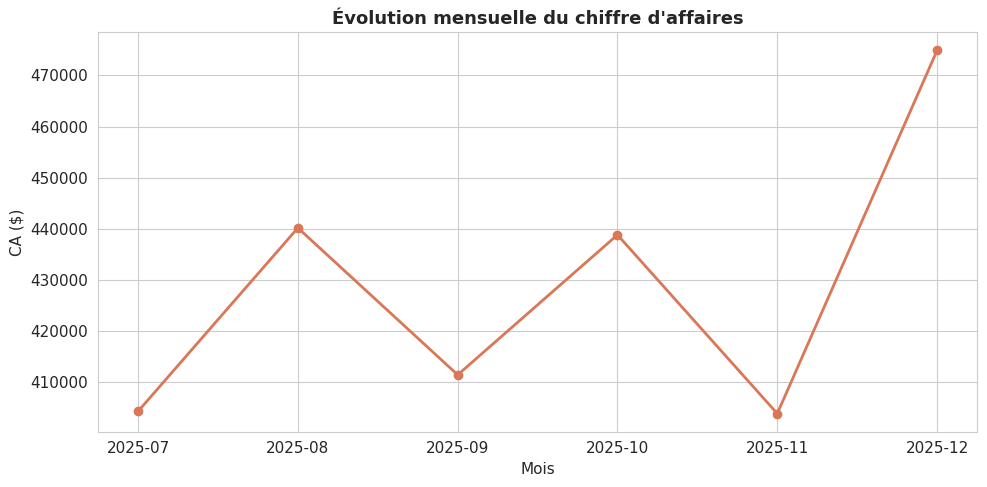

In [12]:
ca_mensuel = df_clean.groupby("mois")["chiffre_affaires"].sum().sort_index()

fig, ax = plt.subplots()
ca_mensuel.plot(kind="line", marker="o", color=COULEUR_PRINCIPALE, linewidth=2, ax=ax)
ax.set_title("Évolution mensuelle du chiffre d'affaires", fontsize=13, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA ($)")
plt.tight_layout()
plt.show()

### 🏷 5.2 Analyse par catégorie

> 💡 **Prompt Claude — Analyse comparative par groupe**
>
> ```
> Fais-moi une analyse par catégorie de produit : CA total, marge brute totale, taux de retour moyen, et évolution mensuelle du CA. Présente un barplot horizontal trié par CA décroissant avec seaborn.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

                        ca          marge  taux_retour
categorie                                             
Électronique  1.918587e+06  805806.646638     0.138390
Maison        3.853907e+05  161864.098956     0.049472
Mode          1.910399e+05   80236.774170     0.074374
Beauté        7.849844e+04   32969.345115     0.027873


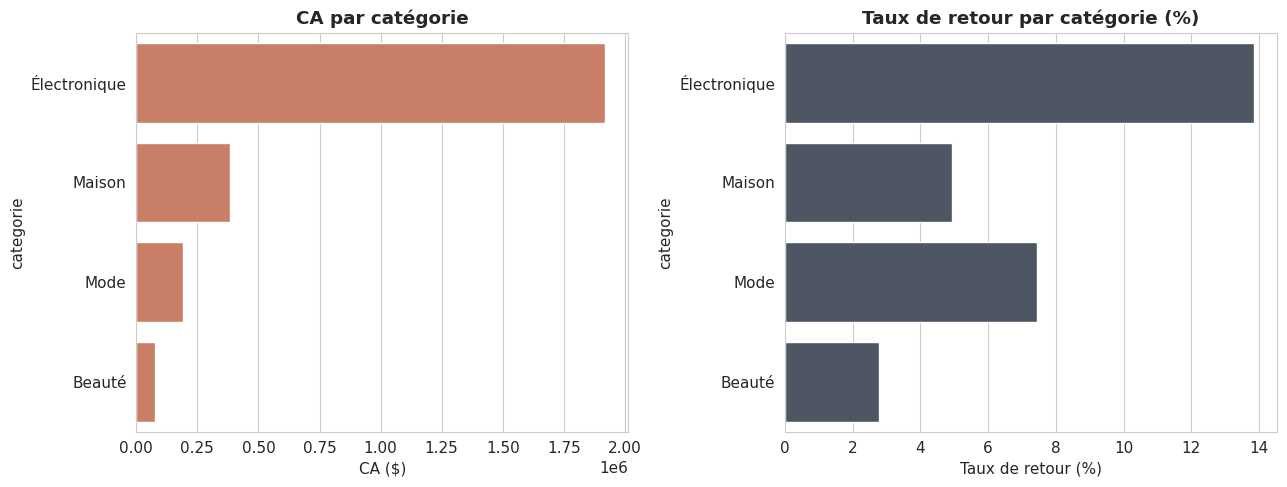

In [13]:
cat_perf = df_clean.groupby("categorie").agg(
    ca=("chiffre_affaires", "sum"),
    marge=("marge_brute", "sum"),
    taux_retour=("indicateur_retour", "mean"),
).sort_values("ca", ascending=False)
print(cat_perf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(y=cat_perf.index, x=cat_perf["ca"], color=COULEUR_PRINCIPALE, ax=axes[0])
axes[0].set_title("CA par catégorie", fontweight="bold")
axes[0].set_xlabel("CA ($)")

sns.barplot(y=cat_perf.index, x=cat_perf["taux_retour"] * 100, color="#4A5568", ax=axes[1])
axes[1].set_title("Taux de retour par catégorie (%)", fontweight="bold")
axes[1].set_xlabel("Taux de retour (%)")
plt.tight_layout()
plt.show()

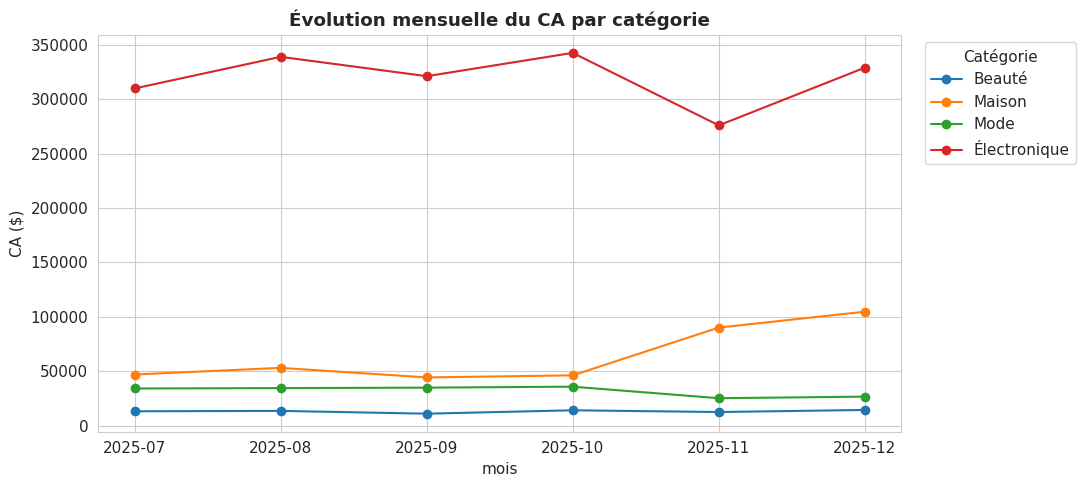

In [14]:
evo_cat = df_clean.groupby(["mois", "categorie"])["chiffre_affaires"].sum().unstack()

fig, ax = plt.subplots(figsize=(11, 5))
evo_cat.plot(kind="line", marker="o", ax=ax)
ax.set_title("Évolution mensuelle du CA par catégorie", fontweight="bold")
ax.set_ylabel("CA ($)")
ax.legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**❓ Question stratégique : quelle catégorie doit être priorisée ou
optimisée ?** L'Électronique génère environ 75% du CA total mais affiche
aussi le taux de retour le plus élevé (voir `cat_perf`). C'est une
catégorie à fort effet de levier : même une petite réduction de son taux
de retour a un impact business disproportionné comparé aux autres
catégories.

### 🌍 5.3 Analyse géographique

> 💡 **Prompt Claude — Analyse par zone géographique**
>
> ```
> Analyse la performance par ville : CA, profit, taux d'annulation, et croissance mensuelle du CA. Identifie les villes qui se démarquent, en positif comme en négatif.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

                       ca         profit  taux_annulation
ville                                                    
Kinshasa     759156.66065  282403.227473         0.002570
Abidjan      504962.87925  188336.849285         0.000000
Douala       381900.61125  142197.936725         0.129222
Dakar        350983.07110  129506.559862         0.000000
Lomé         185067.10370   68495.323554         0.000000
Cotonou      159799.03160   58873.813272         0.000000
Libreville   124612.29590   45873.534278         0.000000
Brazzaville  107034.69150   39237.930430         0.000000


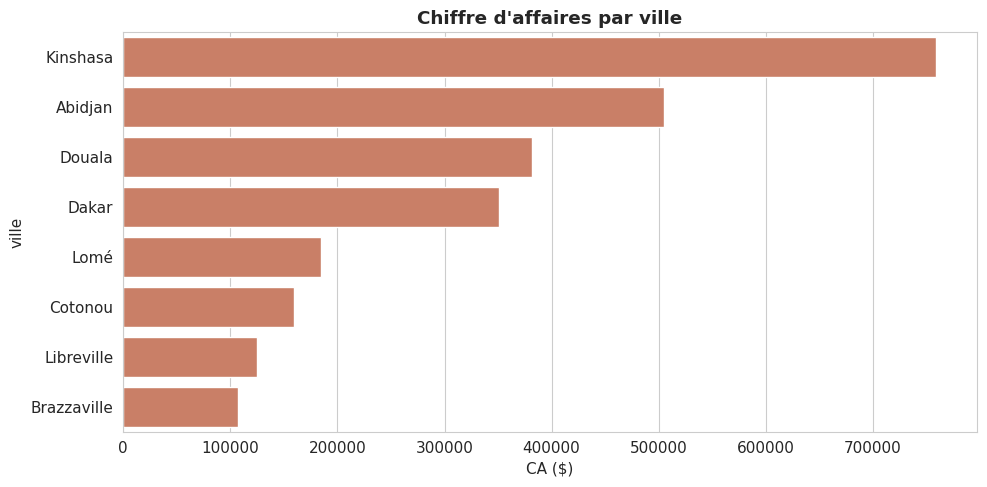

In [15]:
geo_perf = df_clean.groupby("ville").agg(
    ca=("chiffre_affaires", "sum"),
    profit=("profit_net", "sum"),
    taux_annulation=("statut_commande", lambda s: (s == "Annulée").mean()),
).sort_values("ca", ascending=False)
print(geo_perf)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(y=geo_perf.index, x=geo_perf["ca"], color=COULEUR_PRINCIPALE, ax=ax)
ax.set_title("Chiffre d'affaires par ville", fontweight="bold")
ax.set_xlabel("CA ($)")
plt.tight_layout()
plt.show()

**🚨 Signal fort à ne pas manquer :** en regardant `taux_annulation` dans
le tableau ci-dessus, une seule ville sort très largement du lot avec un
taux d'annulation nettement supérieur aux autres, qui sont proches de zéro.
Ce n'est **pas du bruit statistique** — c'est le genre d'anomalie qu'un(e)
Data Analyst doit remonter immédiatement à la direction, car elle pointe
vers un problème opérationnel localisé (logistique, paiement à la
livraison, concurrence locale...) plutôt qu'un problème structurel de
toute l'entreprise.

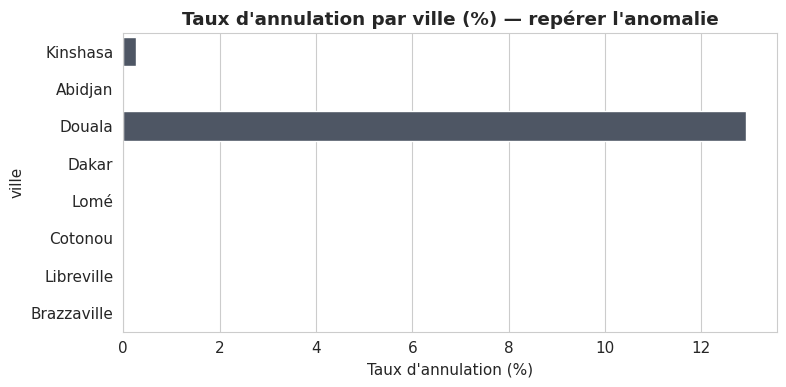

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(y=geo_perf.index, x=geo_perf["taux_annulation"] * 100, color="#4A5568", ax=ax)
ax.set_title("Taux d'annulation par ville (%) — repérer l'anomalie", fontweight="bold")
ax.set_xlabel("Taux d'annulation (%)")
plt.tight_layout()
plt.show()

**❓ Question stratégique : où devons-nous investir davantage ?** En
excluant la ville anormale (à traiter en priorité comme un incident, pas
comme une opportunité d'investissement), les villes à CA plus modeste mais
sans signal d'alerte sont de meilleurs candidats à un investissement
marketing additionnel que la ville la plus mature.

### 📢 5.4 Analyse marketing

> 💡 **Prompt Claude — Calculer un ROI marketing par canal**
>
> ```
> Calcule le ROI marketing par canal d'acquisition avec la formule ROI = (Revenus - Coût marketing) / Coût marketing. Trie les canaux par ROI et affiche aussi le CA absolu de chaque canal à côté.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [17]:
mkt_perf = df_clean.groupby("canal_marketing").agg(
    ca=("chiffre_affaires", "sum"),
    cout=("cout_marketing", "sum"),
).reset_index()
mkt_perf["roi"] = (mkt_perf["ca"] - mkt_perf["cout"]) / mkt_perf["cout"]

retention = df_clean.groupby(["canal_marketing", "id_client"])["id_commande"].count().reset_index()
retention["recurrent"] = retention["id_commande"] > 1
taux_retention = retention.groupby("canal_marketing")["recurrent"].mean()
mkt_perf["taux_retention"] = mkt_perf["canal_marketing"].map(taux_retention)

print(mkt_perf.sort_values("ca", ascending=False).round(2))

  canal_marketing         ca      cout     roi  taux_retention
3   Instagram Ads  973702.79  37637.07   24.87            0.54
1      Google Ads  678960.15  13158.93   50.60            0.50
0           Email  548845.02   2349.15  232.64            0.46
2     Influenceur  372008.38  16359.59   21.74            0.42


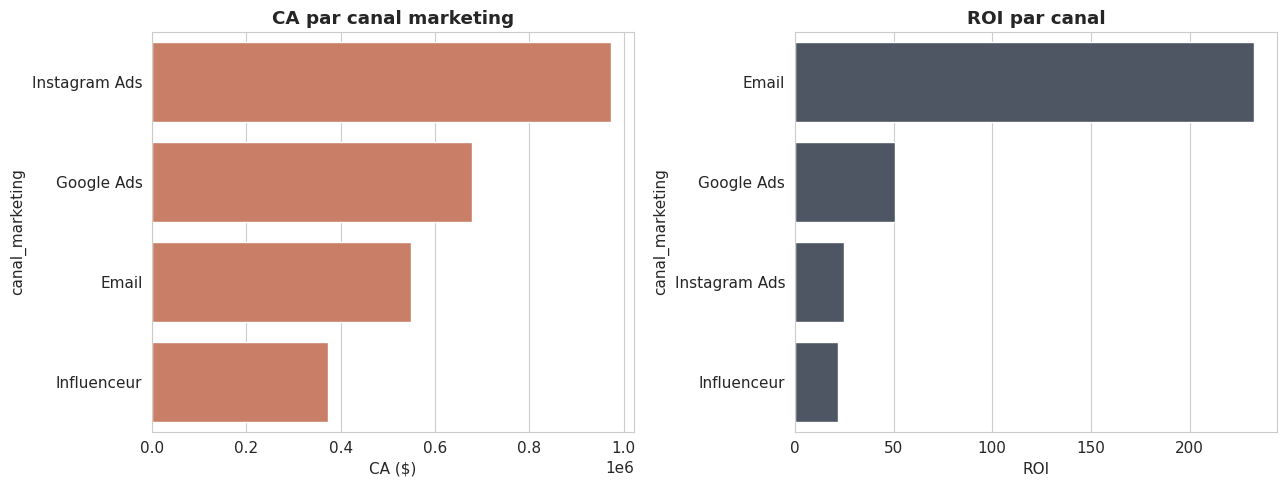

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mkt_sorted = mkt_perf.sort_values("ca", ascending=False)
sns.barplot(y=mkt_sorted["canal_marketing"], x=mkt_sorted["ca"], color=COULEUR_PRINCIPALE, ax=axes[0])
axes[0].set_title("CA par canal marketing", fontweight="bold")
axes[0].set_xlabel("CA ($)")

mkt_roi = mkt_perf.sort_values("roi", ascending=False)
sns.barplot(y=mkt_roi["canal_marketing"], x=mkt_roi["roi"], color="#4A5568", ax=axes[1])
axes[1].set_title("ROI par canal", fontweight="bold")
axes[1].set_xlabel("ROI")
plt.tight_layout()
plt.show()

> ⚠️ **Piège d'interprétation classique** : Email affiche un ROI très
> supérieur aux autres canaux, mais sur un volume de CA nettement plus
> faible qu'Instagram Ads. Un ROI élevé sur un petit volume ne veut pas
> dire "canal à scaler à l'infini" — un budget marketing dupliqué sur Email
> rencontrerait vite des rendements décroissants (saturation de la liste de
> contacts). Il faut toujours lire le ROI **avec** le CA absolu à côté.

**❓ Question stratégique : quel canal mérite plus de budget ? Lequel doit
être optimisé ou réduit ?** Google Ads combine un bon ROI **et** un volume
de CA conséquent : c'est le meilleur candidat à un investissement
additionnel, avant même Email (ROI plus élevé mais volume limité) et avant
Instagram Ads (plus gros volume mais ROI le plus faible, donc à optimiser
plutôt qu'à augmenter tel quel).

### 💳 5.5 Analyse complémentaire — méthode de paiement

> 💡 **Prompt Claude — Explorer une dimension supplémentaire du dataset**
>
> ```
> Le dataset contient aussi une colonne methode_paiement. Vérifie si le taux d'annulation ou de retour varie significativement selon le mode de paiement utilisé.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

In [19]:
pay_perf = df_clean.groupby("methode_paiement").agg(
    ca=("chiffre_affaires", "sum"),
    taux_annulation=("statut_commande", lambda s: (s == "Annulée").mean()),
    taux_retour=("indicateur_retour", "mean"),
).sort_values("ca", ascending=False)
print(pay_perf)

                                   ca  taux_annulation  taux_retour
methode_paiement                                                   
Paiement à la livraison  658036.90430         0.018418     0.077438
Mobile Money             646163.25335         0.020068     0.090094
Carte                    642080.60375         0.021039     0.079004
Virement                 627235.58355         0.018376     0.079060


**Constat :** contrairement à la dimension géographique, la méthode de
paiement ne montre pas d'écart marquant de taux d'annulation ou de retour —
les 4 méthodes se comportent de façon assez homogène. C'est un résultat en
soi : ça permet d'écarter l'hypothèse "le paiement à la livraison cause plus
d'annulations" et de concentrer l'attention sur la piste géographique
identifiée plus haut.

### 👥 5.6 Analyse clients

> 💡 **Prompt Claude — Analyse Pareto (règle des 80/20) et segmentation clients**
>
> ```
> Fais une analyse Pareto (80/20) sur mes clients : quel pourcentage de clients génère 80% du chiffre d'affaires ? Donne-moi aussi le top 10 clients par valeur vie client, et une segmentation simple (occasionnels / réguliers / VIP) basée sur le nombre de commandes.
> ```
> C'est exactement ce type de prompt que tu peux copier-coller dans Claude pour obtenir ou faire vérifier ce bloc de code.

Nombre total de clients : 1747
% de clients récurrents : 74.0%

% de clients qui génèrent 80% du CA : 31.8%


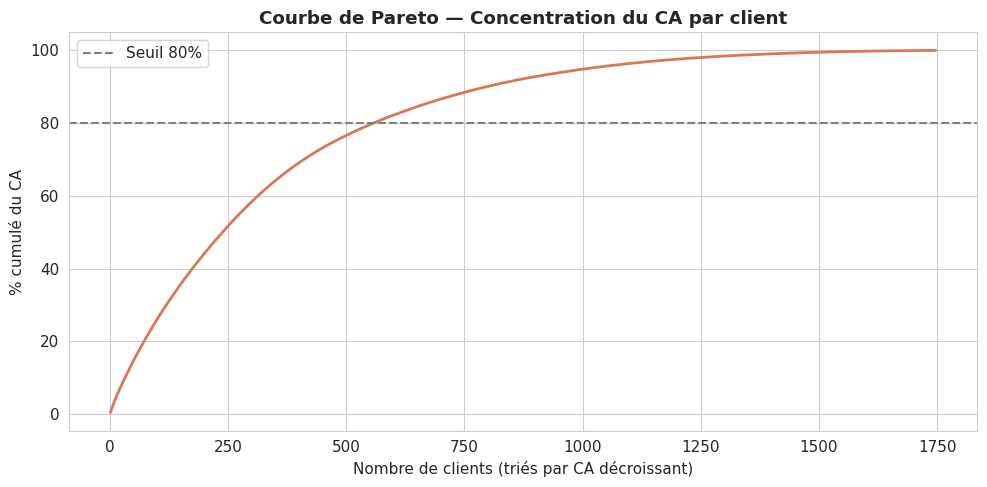

In [20]:
n_clients_total = df_clean["id_client"].nunique()
pct_recurrents = (df_clean.groupby("id_client")["id_commande"].count() > 1).mean()
print(f"Nombre total de clients : {n_clients_total}")
print(f"% de clients récurrents : {pct_recurrents:.1%}")

clv_par_client = df_clean.groupby("id_client")["chiffre_affaires"].sum().sort_values(ascending=False)
cumul_pct = clv_par_client.cumsum() / clv_par_client.sum()
pct_clients_pour_80 = (cumul_pct <= 0.8).sum() / len(cumul_pct)
print(f"\n% de clients qui génèrent 80% du CA : {pct_clients_pour_80:.1%}")

fig, ax = plt.subplots()
ax.plot(range(1, len(cumul_pct) + 1), cumul_pct.values * 100, color=COULEUR_PRINCIPALE, linewidth=2)
ax.axhline(80, color="grey", linestyle="--", label="Seuil 80%")
ax.set_title("Courbe de Pareto — Concentration du CA par client", fontweight="bold")
ax.set_xlabel("Nombre de clients (triés par CA décroissant)")
ax.set_ylabel("% cumulé du CA")
ax.legend()
plt.tight_layout()
plt.show()

Top 10 clients par valeur vie client (CLV) :
id_client
C0157    11575.7
C0266    10830.7
C0003     9641.0
C0120     9592.0
C0051     9569.6
C0001     9178.0
C0379     9070.7
C0114     8941.7
C0067     8838.2
C0184     8549.3
Name: chiffre_affaires, dtype: float64

Répartition des segments clients :
id_commande
Régulier       819
VIP            474
Occasionnel    454
Name: count, dtype: int64


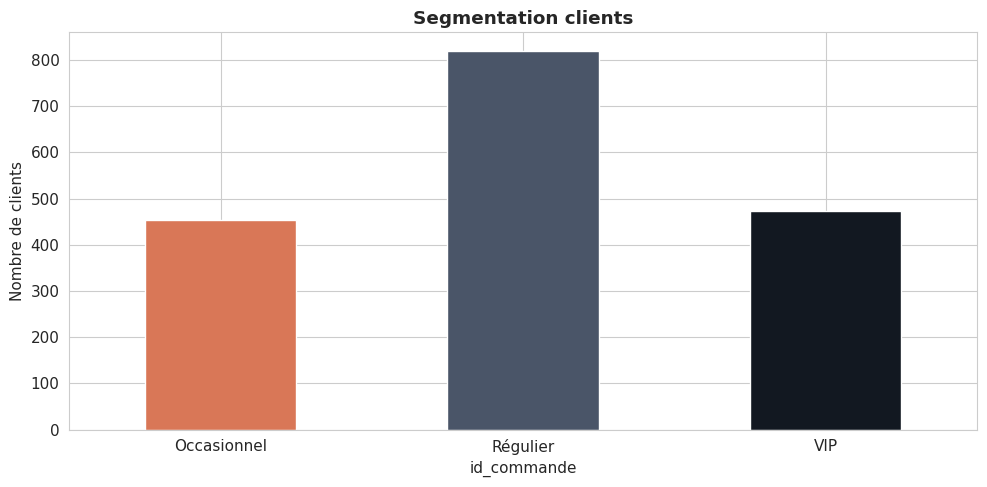

In [21]:
print("Top 10 clients par valeur vie client (CLV) :")
print(clv_par_client.head(10).round(1))

nb_commandes = df_clean.groupby("id_client")["id_commande"].count()

def segmenter(n):
    if n == 1:
        return "Occasionnel"
    elif n <= 4:
        return "Régulier"
    return "VIP"

segments = nb_commandes.apply(segmenter)
print("\nRépartition des segments clients :")
print(segments.value_counts())

fig, ax = plt.subplots()
segments.value_counts().reindex(["Occasionnel", "Régulier", "VIP"]).plot(
    kind="bar", color=["#D97757", "#4A5568", "#121821"], ax=ax
)
ax.set_title("Segmentation clients", fontweight="bold")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**❓ Question stratégique : comment améliorer la rétention ?** Avec 74%
de clients récurrents, AfriMarket a déjà une base fidèle solide — l'enjeu
n'est donc pas tant d'augmenter la rétention brute que de faire progresser
le segment **Régulier** vers le segment **VIP**, là où se concentre la
valeur (environ 32% des clients génèrent 80% du CA).

### 🔥 5.7 Heatmap — CA par ville et catégorie

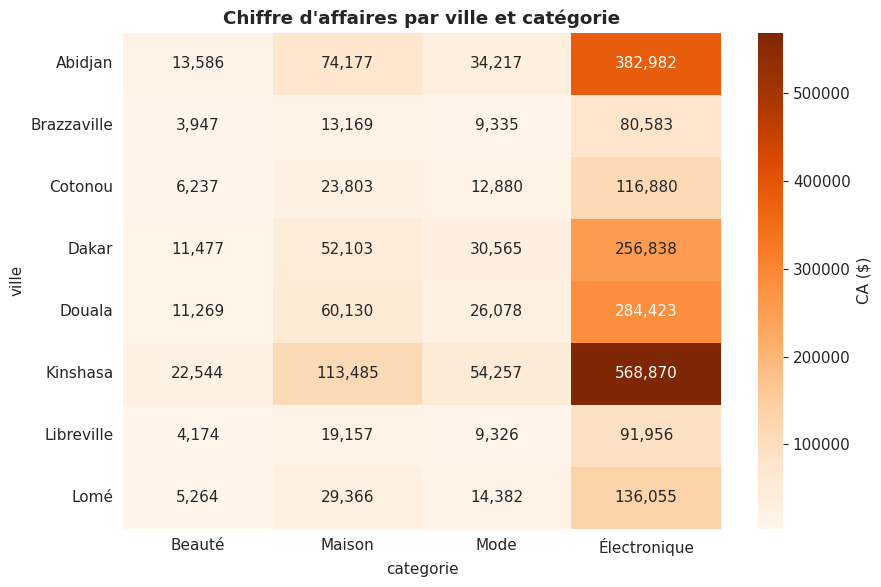

In [22]:
pivot = df_clean.pivot_table(values="chiffre_affaires", index="ville", columns="categorie", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="Oranges", ax=ax, cbar_kws={"label": "CA ($)"})
ax.set_title("Chiffre d'affaires par ville et catégorie", fontweight="bold")
plt.tight_layout()
plt.show()

Cette heatmap confirme que l'Électronique domine partout, mais dans des
proportions variables selon la ville — utile pour calibrer des campagnes
marketing géo-localisées par catégorie plutôt que génériques.

## 6️⃣ Export du dataset propre

On sauvegarde `df_clean` pour qu'il puisse être réutilisé directement par
le dashboard Streamlit (`app.py`).

In [23]:
df_clean.to_csv("afrimarket_clean.csv", index=False)
print(f"Dataset propre exporté : afrimarket_clean.csv ({df_clean.shape[0]} lignes)")

Dataset propre exporté : afrimarket_clean.csv (9400 lignes)


## 7️⃣ Résumé exécutif

*(Résumé généré à partir des résultats calculés ci-dessus sur le dataset
réel fourni.)*

**AfriMarket — Synthèse 6 mois d'activité (juillet–décembre 2025)**

Sur la période analysée, AfriMarket a généré un chiffre d'affaires total
d'environ **2 573 500 $** pour un profit net estimé de **955 000 $**, avec
un panier moyen de **274 $**. Le taux d'annulation global (1,9%) est bas,
mais **cache une anomalie géographique majeure** : le taux d'annulation
grimpe à environ 13% à Douala, contre un niveau proche de zéro partout
ailleurs — un signal opérationnel à traiter en priorité. Le taux de retour
(8,1%) est concentré sur la catégorie Électronique (13,8%), qui représente
à elle seule près de 75% du chiffre d'affaires total.

Géographiquement, Kinshasa reste le marché le plus important (759 000 $ de
CA), mais Douala illustre qu'un CA élevé peut masquer un problème
opérationnel local sérieux.

Côté marketing, Google Ads combine le meilleur équilibre volume/ROI parmi
les canaux analysés, tandis qu'Instagram Ads génère le plus gros volume de
CA mais avec le ROI le plus faible, et qu'Email affiche le ROI le plus
élevé mais sur un volume limité.

Enfin, l'analyse clients montre une base déjà fidèle (74% de clients
récurrents), avec environ 32% des clients générant 80% du chiffre
d'affaires — l'enjeu de rétention porte donc surtout sur la conversion des
clients "Réguliers" en "VIP".

## 8️⃣ Recommandations stratégiques

1. **Investiguer en urgence l'anomalie d'annulation à Douala** (~13% contre
   ~0-2% ailleurs) : probablement un problème logistique, de paiement à la
   livraison, ou de concurrence locale — c'est le signal le plus actionnable
   de toute l'analyse.
2. **Auditer la qualité produit en Électronique** : cette catégorie porte
   ~75% du CA mais aussi le taux de retour le plus élevé — un audit
   fournisseur/qualité peut sécuriser une part disproportionnée de la marge.
3. **Prioriser Google Ads pour un investissement marketing additionnel**
   (bon ROI ET volume conséquent), tout en travaillant l'optimisation du
   ciblage d'Instagram Ads plutôt que de simplement réduire son budget vu
   son poids dans le CA total.
4. **Lancer un programme de fidélisation ciblé sur le segment "Régulier"**
   pour le faire basculer en VIP, la base de clients occasionnels étant déjà
   réduite (74% de récurrence).
5. **Mettre en place un contrôle de saisie côté CRM/formulaire** (villes,
   catégories, prix, remises) pour éviter la répétition des incohérences
   détectées lors de l'audit, notamment les valeurs sentinelles d'erreur sur
   les prix et les remises.

## Conclusion

Ce projet montre qu'une bonne partie de la valeur d'une analyse data ne vient
pas des graphiques finaux, mais de la rigueur du nettoyage, de la
vérification des hypothèses de correction (prix négatifs vs signe inversé),
et de la capacité à repérer un signal fort caché derrière une moyenne
globale rassurante — ici, l'anomalie d'annulation à Douala. AfriMarket
dispose d'une base clients fidèle et d'un canal e-commerce rentable ; les
prochaines actions doivent viser la résolution de ce problème opérationnel
localisé et la qualité produit en Électronique plus que la seule
acquisition de nouveaux clients.